In [1]:
import os
from osgeo import gdal, ogr
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from train_voter import load_and_preprocess_image
from sklearn.cluster import KMeans
from skimage.feature import greycomatrix, greycoprops
from skimage.measure import shannon_entropy
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import plotly.express as px
from ipywidgets import Dropdown, interact

In [2]:
# Load the GeoPackage
city = 'ACC'
grd_sz = 200
tiles_path = f'clustering/{city}/{city}_LCZ_morph_complete_200m.gpkg'
lcz_metrics_gdf = gpd.read_file(tiles_path)
city_tiles = gpd.read_file(f'clustering/{city}/{city}_FN_{grd_sz}m.gpkg')

In [3]:
for c in lcz_metrics_gdf.columns[2:25]:
    print(c)

stcOri
sdcLAL
sdcAre
sscCCo
sscERI
mtcWNe
mdcAre
sicCAR
ssbCCM
ssbCCD
mtbAli
mtbNDi
ltbIBD
ltcBuA
geometry


In [4]:
cols = ['sicCAR']
not_cols = ['PARTIMAP_I', 'geometry']

In [158]:
# tiles_metrics_lcz = city_tiles[['PARTIMAP_I','geometry']].merge(lcz_metrics_gdf, on='PARTIMAP_I',how='right')
# tiles_metrics_lcz.to_file(f'clustering/{city}/{city}_LCZ_morph_complete_200m.gpkg', driver='GPKG')

In [169]:
def apply_gaussian_mixture(group, feature_cols, n_components, label_offset):
    try:
        gmm = GaussianMixture(n_components=n_components, random_state=0)
        cluster_labels = gmm.fit_predict(group[feature_cols])  # Get cluster labels

        # Check cluster sizes *before* adding the offset
        cluster_sizes = pd.Series(cluster_labels).value_counts()  # Use pd.Series
        if (cluster_sizes < 10).any():
            raise ValueError("One or more clusters have less than 10 entries.")

        group['cluster'] = cluster_labels + label_offset  # Add offset after checks

        # Calculate Silhouette Score (handle single cluster case)
        if len(set(cluster_labels)) > 1:
            silhouette = silhouette_score(group[feature_cols], cluster_labels)
        else:
            silhouette = None

        # Calculate Davies-Bouldin Index
        db_index = davies_bouldin_score(group[feature_cols], cluster_labels)

        return group, silhouette, db_index  # Return metrics

    except ValueError as e:
        print(f"Clustering for LCZ failed: {e}")
        group['cluster'] = 1 + label_offset  # Assign to a single cluster on failure
        return group, None, None # Return group and None for metrics

n_components = 2  # Number of components for GMM
label_offset = 0
result_df = pd.DataFrame()
silhouette_scores = []
db_indices = []

# Apply Gaussian Mixture clustering within each LCZ group and adjust cluster labels
for name, group in lcz_metrics_gdf.groupby('LCZ'):
    clustered_group, silhouette, db_index = apply_gaussian_mixture(group, feature_cols=cols, n_components=n_components, label_offset=label_offset)
    result_df = pd.concat([result_df, clustered_group])
    label_offset += n_components

    silhouette_scores.append(silhouette)
    db_indices.append(db_index)

# Reset index if necessary
result_df = result_df.reset_index(drop=True)

# Print or analyze the scores
print("Silhouette Scores for each LCZ:", silhouette_scores)
print("Davies-Bouldin Indices for each LCZ:", db_indices)

# Calculate and print the average scores (excluding None values)
avg_silhouette = sum(s for s in silhouette_scores if s is not None) / len([s for s in silhouette_scores if s is not None]) if any(s is not None for s in silhouette_scores) else None

avg_db_index = sum(db for db in db_indices if db is not None) / len([db for db in db_indices if db is not None]) if any(db is not None for db in db_indices) else None


print(f"Average Silhouette Score: {avg_silhouette}")
print(f"Average Davies-Bouldin Index: {avg_db_index}")

Silhouette Scores for each LCZ: [0.5716862530341754, 0.5711124216863126, 0.5973750753883328, 0.6755743485278805, 0.40115782937580585]
Davies-Bouldin Indices for each LCZ: [0.5676971854386742, 0.5711128323567095, 0.5398543339135637, 0.39036080076914415, 0.46637089358098593]
Average Silhouette Score: 0.5633811856025014
Average Davies-Bouldin Index: 0.5070792092118155


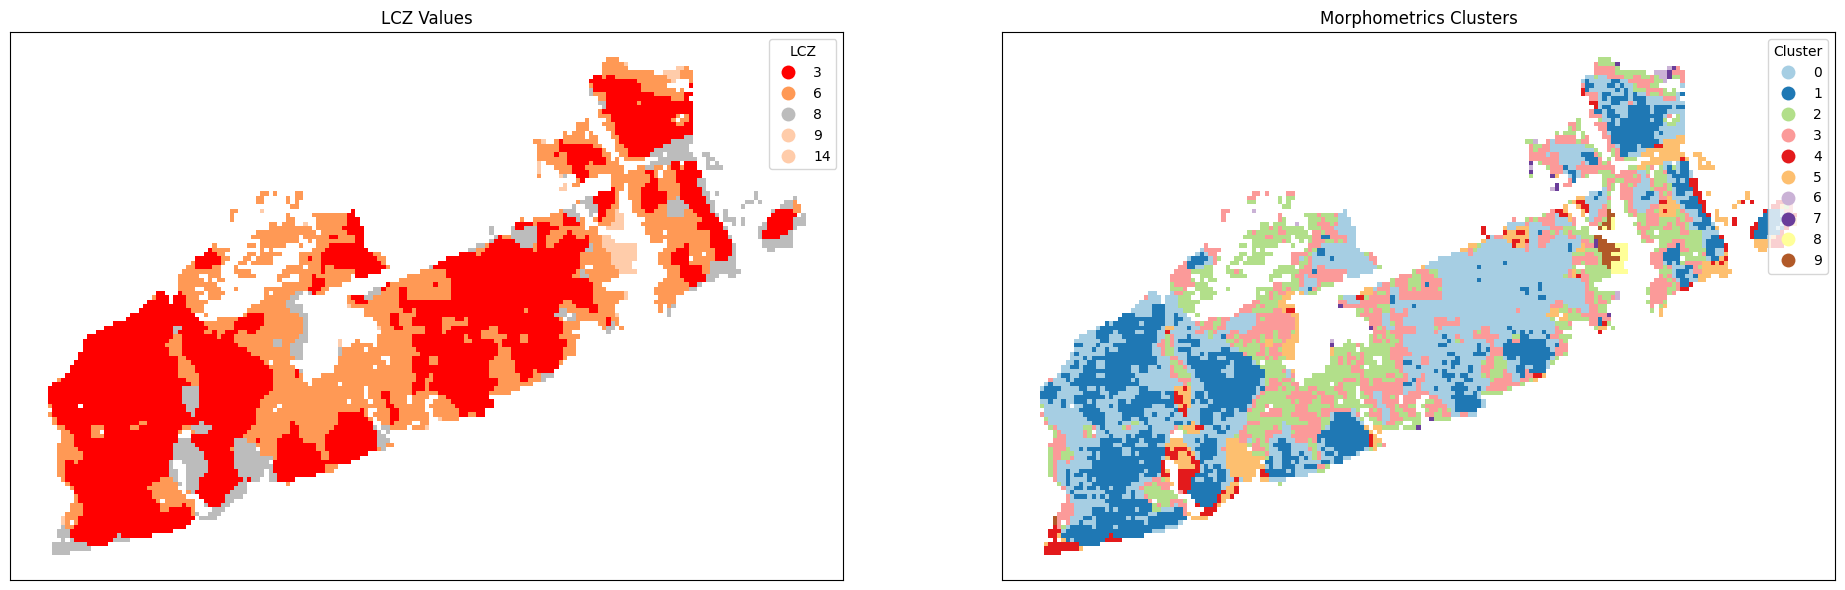

In [7]:
# colors = ['#d10000', '#ff0000', '#ff6600', '#ff9955', '#bcbcbc','#ffccaa'] #NBO
colors = ['#ff0000', '#ff9955', '#bcbcbc','#ffccaa'] #NBO_PARTIMAP
custom_cmap = ListedColormap(colors)

# Create figure and subplots
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(20, 6))

# Plot KMeans clusters
scatter1 = result_df.plot(column='cluster', categorical=True, legend=True, 
                   legend_kwds={'title': 'Cluster'}, ax=ax1, cmap = "Paired")
ax1.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax1.set_title('Morphometrics Clusters')

# Plot LCZ values
scatter2 = result_df.plot(column='LCZ', categorical=True, legend=True, 
                   legend_kwds={'title': 'LCZ'}, ax=ax2, cmap = custom_cmap)
ax2.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax2.set_title('LCZ Values')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

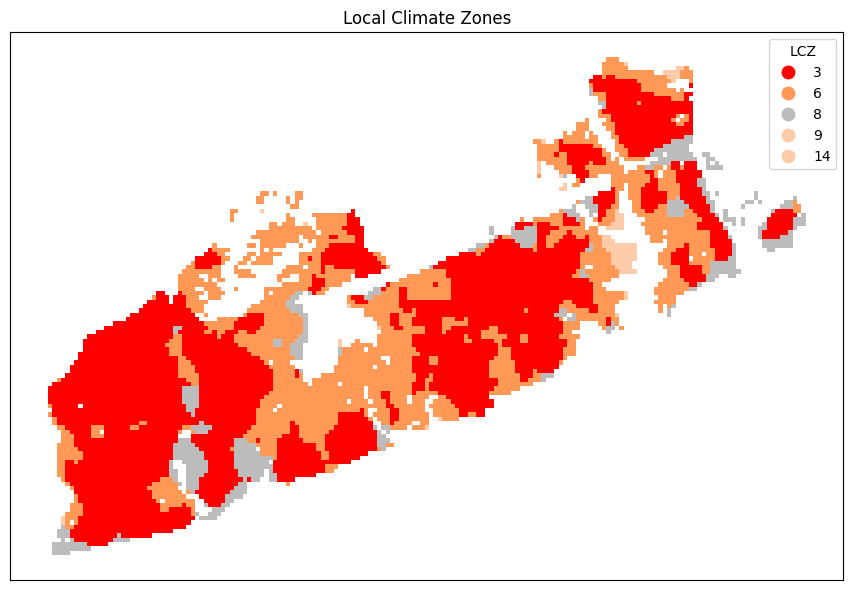

In [172]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
colors = ['#ff0000', '#ff9955', '#bcbcbc','#ffccaa'] #NBO_PARTIMAP

custom_cmap = ListedColormap(colors)
result_df.plot(column='LCZ', categorical=True, legend=True, 
                   legend_kwds={'title': 'LCZ'}, ax=ax, cmap=custom_cmap)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
# Set the title and show the plot
ax.set_title('Local Climate Zones')
plt.tight_layout()
plt.savefig(f'clustering/figs/{city}_sicCAR_PMAP_LCZs_map.jpg', format='jpg', dpi=300)
plt.show()

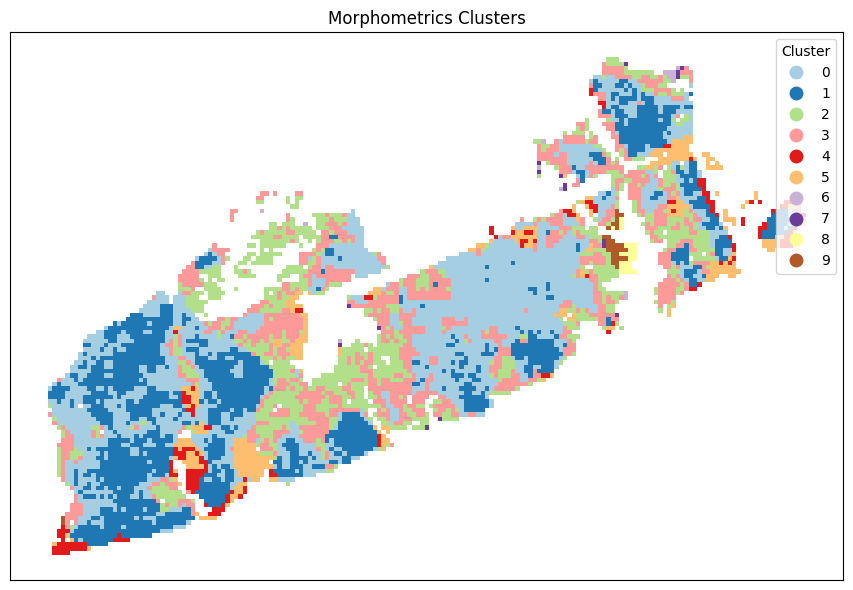

In [173]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
result_df.plot(column='cluster', categorical=True, legend=True, 
                     legend_kwds={'title': 'Cluster'}, ax=ax, cmap = "Paired")
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
# Set the title and show the plot
ax.set_title('Morphometrics Clusters')
plt.tight_layout()
plt.savefig(f'clustering/figs/{city}_PMAP_km_sicCAR_map.jpg', format='jpg', dpi=300)
plt.show()

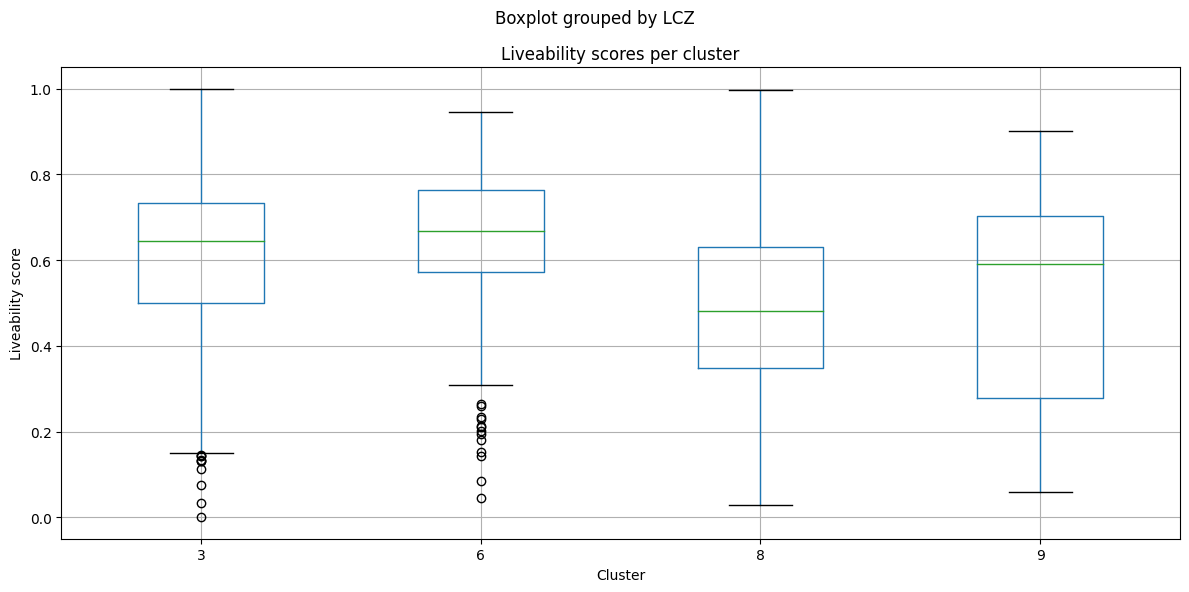

In [21]:
plot_oa = tiles_metrics
group_score = ['LCZ']

fig, ax = plt.subplots(figsize=(12,6))
plot_oa.boxplot(column='n_ts_v', by=group_score, ax=ax, patch_artist=False)
ax.set_xlabel('Cluster')
ax.set_ylabel('Liveability score')
# ax.set_ylim(0.5, 0.6)
# Show the legend
ax.set_title("Liveability scores per cluster")
fig.tight_layout()
plt.savefig('clustering/figs/NBO_PMAP_liveability_LCZ_boxplot.jpg', format='jpg', dpi=300)
plt.show()

In [31]:
print(tiles_metrics['LCZ'].value_counts().sort_index())
model = ols('n_ts_v ~ C(LCZ)', data=tiles_metrics).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA results:")
print(anova_table)

# If the ANOVA is significant, perform post-hoc test
if anova_table['PR(>F)'][0] < 0.001:
    print("\nPost-hoc test (Tukey's HSD):")
    tukey = pairwise_tukeyhsd(endog=tiles_metrics['n_ts_v'], groups=tiles_metrics['LCZ'], alpha=0.001)
    print(tukey)
else:
    print("\nANOVA is not significant, no need for post-hoc test.")

3    821
6    357
8    788
9     17
Name: LCZ, dtype: int64
ANOVA results:
             sum_sq      df          F        PR(>F)
C(LCZ)     8.509132     3.0  89.002365  5.026962e-54
Residual  63.067880  1979.0        NaN           NaN

Post-hoc test (Tukey's HSD):
Multiple Comparison of Means - Tukey HSD, FWER=0.00 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     3      6   0.0379 0.0046 -0.0047  0.0805  False
     3      8  -0.1193   -0.0 -0.1528 -0.0858   True
     3      9  -0.1071 0.0686 -0.2716  0.0574  False
     6      8  -0.1572   -0.0 -0.2001 -0.1144   True
     6      9   -0.145  0.006 -0.3117  0.0216  False
     8      9   0.0122 0.9924 -0.1524  0.1768  False
----------------------------------------------------


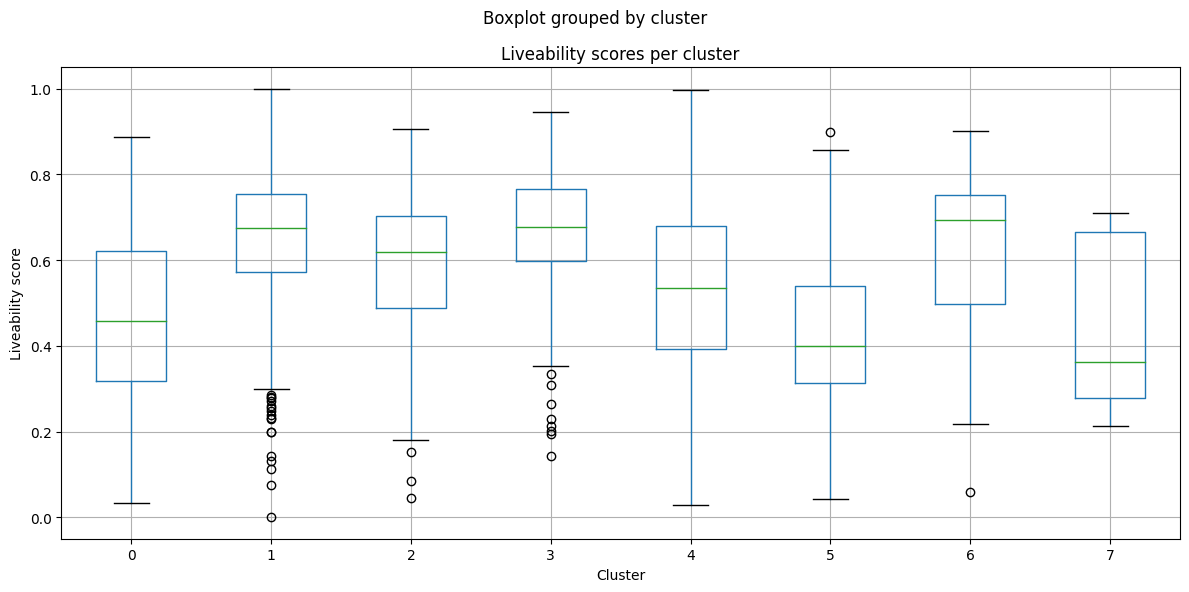

In [22]:
plot_oa = tiles_metrics
group_score = ['cluster']

fig, ax = plt.subplots(figsize=(12,6))
plot_oa.boxplot(column='n_ts_v', by=group_score, ax=ax, patch_artist=False)
ax.set_xlabel('Cluster')
ax.set_ylabel('Liveability score')
# ax.set_ylim(0.5, 0.6)
# Show the legend
ax.set_title("Liveability scores per cluster")
fig.tight_layout()
plt.savefig('clustering/figs/NBO_PMAP_liveability_cluster_boxplot.jpg', format='jpg', dpi=300)
plt.show()

In [ ]:
plot_oa = tiles_metrics
group_score = ['LCZ']

fig, ax = plt.subplots(figsize=(12,6))
plot_oa.boxplot(column='ltbIBD', by=group_score, ax=ax, patch_artist=False)
ax.set_xlabel('Cluster')
ax.set_ylabel('MIBD')
# ax.set_ylim(0.5, 0.6)
# Show the legend
ax.set_title("Mean inter-building distance per LCZ")
fig.tight_layout()
# plt.savefig('clustering/figs/NBO_mibd_LCZ_boxplot.jpg', format='jpg', dpi=300)
plt.show()

In [15]:
# Create a dictionary to store the results
results = {}

# Iterate over the cluster pairs
for i in range(0, 8, 2):
    # Filter the scores for the two clusters
    cluster_a_scores = tiles_metrics[tiles_metrics['cluster'] == i]['n_ts_v']
    cluster_b_scores = tiles_metrics[tiles_metrics['cluster'] == i + 1]['n_ts_v']
    
    # Perform a t-test
    t_stat, p_value = ttest_ind(cluster_a_scores, cluster_b_scores)
    if p_value < 0.001:
        sig = 1
    else:
        sig = 0
    # Store the result
    results[f'Cluster {i} vs Cluster {i+1}'] = {'t_stat': t_stat, 'p_value': p_value, 'sig': sig}

# Convert results to a DataFrame for better readability
results_df = pd.DataFrame(results).T

# Display the results
print(results_df)

                           t_stat       p_value  sig
Cluster 0 vs Cluster 1 -14.399527  4.521514e-42  1.0
Cluster 2 vs Cluster 3  -4.185727  3.588089e-05  1.0
Cluster 4 vs Cluster 5   8.217575  8.533562e-16  1.0
Cluster 6 vs Cluster 7   1.305223  2.114844e-01  0.0


In [29]:
print(tiles_metrics['cluster'].value_counts().sort_index())
model = ols('n_ts_v ~ C(cluster)', data=tiles_metrics).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA results:")
print(anova_table)

# If the ANOVA is significant, perform post-hoc test
if anova_table['PR(>F)'][0] < 0.001:
    print("\nPost-hoc test (Tukey's HSD):")
    tukey = pairwise_tukeyhsd(endog=tiles_metrics['n_ts_v'], groups=tiles_metrics['cluster'], alpha=0.001)
    print(tukey)
else:
    print("\nANOVA is not significant, no need for post-hoc test.")

0    203
1    618
2     84
3    273
4    473
5    315
6      8
7      9
Name: cluster, dtype: int64
ANOVA results:
               sum_sq      df          F         PR(>F)
C(cluster)  16.501771     7.0  84.536296  9.611809e-108
Residual    55.075241  1975.0        NaN            NaN

Post-hoc test (Tukey's HSD):
Multiple Comparison of Means - Tukey HSD, FWER=0.00 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   0.1872    0.0  0.1315  0.2429   True
     0      2   0.1178    0.0  0.0284  0.2072   True
     0      3   0.1976    0.0  0.1337  0.2614   True
     0      4    0.064 0.0001  0.0061  0.1218   True
     0      5   -0.042 0.0969  -0.104    0.02  False
     0      6   0.1175 0.5154 -0.1309  0.3658  False
     0      7  -0.0406 0.9966 -0.2753  0.1942  False
     1      2  -0.0694 0.0087 -0.1495  0.0108  False
     1      3   0.0104 0.9897 -0.0397  0.0605  False
     1      4  -0.1232    0.0 -0.1653 -0.0811   Tru

In [8]:
result_df.to_file(f'clustering/{city}/{city}_LCZ_morph_km_sicCAR_200m.gpkg', driver='GPKG')